# When research concepts were officially recognised: `data.py` demo

This notebook is a runnable walk-through of **`data.py`**, the last step of the dataset artifact that builds an
**external-recognition lookup table** (outcome *O5*) for the 65,026 OpenAlex legacy concepts.

For each concept the artifact records **dated, sourced recognition events** from sources that are independent of
the publication network:
* **MeSH 2026**, with the `DateIntroduced` year of each descriptor;
* **English Wikipedia** page-creation dates (exact first revisions, or a calibrated page-id estimate);
* **Wikidata** P571/P575 (inception and discovery dates);
* dated **taxonomies**: ACM CCS 1998/2012, MSC 2000/2010/2020 and PACS 2010/PhySH;
* **curated yearly lists**: Nature Methods Method of the Year, Science and Physics World Breakthrough of the Year,
  MIT TR10, the Gartner Hype Cycle and Clarivate/CAS Research Fronts.

Each event carries `year_usable`, `match_method`, `match_confidence` and `relation` (same/narrower/broader).
`sources_checked` records found / not_found / not_applicable for every source, and present-day facts sit in a
separate `present_day` block.

**What `data.py` does.** It takes the assembled concept rows and turns them into the `exp_sel_data_out` schema, one
example per row. It then runs schema-level sanity checks, logs the dataset counts and the provisional
dev/heldout fold split, and writes `full_data_out.json`. If that file is larger than the size limit, it splits it
into numbered parts. Finally it writes the stratified `mini_data_out.json` and the truncated `preview_data_out.json`.

**What changes in this demo.** The upstream pipeline steps (s0 to s9) need gigabytes of downloads, so they are not
re-run here. `build_datasets(R)` from `scripts/s9_outputs.py` normally builds the datasets from
`work/concept_rows.pkl`. In this notebook they are **loaded from `mini_demo_data.json`** instead: a curated
100-concept subset of the `concept_recognition` dataset that includes the known-answer concepts (optogenetics,
iPSC, CRISPR, super-resolution microscopy). Everything after that point is the original `data.py` code. The small
helpers it imports from `s9_outputs.py` (`clean`, `dumps`, `write_parts`, `trunc`) are copied in verbatim.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# pandas, pyarrow, matplotlib (numpy) — pre-installed on Colab, install locally only at Colab's versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'pyarrow==18.1.0', 'matplotlib==3.10.0')

## Imports

This is the original import block of `data.py`. Two lines are changed:
* `ROOT` is the notebook's working directory, because a notebook has no `__file__`.
* `from s9_outputs import build_datasets, trunc, write_parts` is replaced. The helpers are defined in a cell below,
  and the datasets come from the loaded JSON.

`matplotlib` is added for the final visualisation.

In [2]:
from __future__ import annotations

import json
import random
import sys
from collections import Counter, defaultdict
from pathlib import Path

ROOT = Path.cwd()  # original: Path(__file__).resolve().parent; sys.path.insert(0, str(ROOT / "scripts"))

import pandas as pd  # noqa: E402
from loguru import logger  # noqa: E402

# original: from s9_outputs import build_datasets, trunc, write_parts  -> helpers defined below, datasets loaded from JSON

import matplotlib.pyplot as plt  # added for the visualisation cell

## Load the demo data

The notebook loads `mini_demo_data.json` from GitHub and falls back to a local copy. The file uses the same
`{"datasets": [{"dataset": ..., "examples": [...]}]}` layout that `build_datasets` returns, and holds a single
dataset (`concept_recognition`).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_AawnV1HvzpNx/round-2/dataset-2/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({d["dataset"]: len(d["examples"]) for d in data["datasets"]})

{'concept_recognition': 100}


## Configuration

These are all the tunable values. Each one is a constant that was hard-coded in `data.py` or `s9_outputs.py`, and
the original value is given in the comment next to it.
* `N_EXAMPLES` sets how many of the 100 demo concept rows are used. The original run used all 65,026 concept rows
  plus 94,704 rows in the 9 other datasets.
* The size limits are scaled down so that the **split-into-parts** branch of `data.py` actually runs on the small
  demo data. With the original 95 MB limit, the demo output would never be split.

In [5]:
N_EXAMPLES = 100                # demo concept rows to use (max 100 in mini_demo_data.json); original: all 65,026 (+94,704 rows in 9 other datasets)
EXPECTED_N_DATASETS = 1         # original: 10 (the demo file holds only concept_recognition)
LIMIT_BYTES = 200_000           # original: 95_000_000 -> full_data_out.json above this is split into parts
PART_BYTES = 150_000            # original: 90_000_000 (s9_outputs.PART_BYTES), max bytes per part
MINI_PER_DATASET = 200          # original: 200 examples per dataset in mini_data_out.json
PREVIEW_PER_DATASET = 10        # original: 10 examples per dataset in preview_data_out.json
REQUIRED = ("input", "output")  # original constant of data.py

## Helpers from `scripts/s9_outputs.py`

These helpers are copied verbatim from `s9_outputs.py`. The only change is that `write_parts` reads the
`PART_BYTES` value from the config cell.
* `clean` and `dumps` serialise to strict JSON: numpy values become Python values, and NaN or inf become `null`.
* `write_parts` splits the list of datasets into numbered `full_data_out_<n>.json` parts, each a valid
  `exp_sel_data_out` document, and keeps the examples of one dataset in order across parts.
* `trunc` shortens long strings for the preview file.

In [6]:
def clean(x):
    """Recursively convert numpy scalars/arrays to Python and NaN/inf to None (strict JSON)."""
    import math
    if isinstance(x, dict):
        return {str(k_): clean(v_) for k_, v_ in x.items()}
    if isinstance(x, (list, tuple)):
        return [clean(y) for y in x]
    if hasattr(x, "tolist") and not isinstance(x, (str, bytes)):
        return clean(x.tolist())
    if isinstance(x, float):
        return None if (math.isnan(x) or math.isinf(x)) else x
    return x


def dumps(x) -> str:
    return json.dumps(clean(x), ensure_ascii=False, allow_nan=False, default=str)


def write_parts(ds: list[dict]) -> list[str]:
    d = ROOT / "full_data_out"
    d.mkdir(exist_ok=True)
    for f in d.glob("full_data_out_*.json"):
        f.unlink()
    parts, cur, cur_bytes = [], [], 0
    meta = {"description": "External, dated recognition events for OpenAlex legacy concepts (zero OpenAlex credits). "
                           "See README.md for field definitions, source biases and lags.",
            "parts_note": "Datasets are split across numbered parts; concatenate examples of equal 'dataset' names."}
    for d_ in ds:
        chunk = []
        for x in d_["examples"]:
            sz = len(dumps(x)) + 2
            if cur_bytes + sz > PART_BYTES and (chunk or cur):  # a new part starts once the running size would exceed PART_BYTES
                if chunk:
                    cur.append({"dataset": d_["dataset"], "examples": chunk})
                parts.append(cur)
                cur, chunk, cur_bytes = [], [], 0
            chunk.append(x)
            cur_bytes += sz
        if chunk:
            cur.append({"dataset": d_["dataset"], "examples": chunk})
    if cur:
        parts.append(cur)
    names = []
    for i, p in enumerate(parts, 1):
        f = d / f"full_data_out_{i}.json"
        f.write_text(json.dumps({"metadata": meta | {"part": i, "n_parts": len(parts)}, "datasets": p}, ensure_ascii=False))
        names.append(str(f.relative_to(ROOT)))
    return names


def trunc(x, n=300):
    if isinstance(x, str):
        return x if len(x) <= n else x[:n] + "..."
    if isinstance(x, list):
        return [trunc(y, n) for y in x]
    if isinstance(x, dict):
        return {k_: trunc(v_, n) for k_, v_ in x.items()}
    return x

## `check`: schema-level sanity checks

`check` enforces rules that the JSON-schema validator does not:
* dataset names are unique, and there is the expected number of them (10 originally, 1 in the demo);
* every dataset is non-empty;
* `input` and `output` are strings (JSON-encoded records);
* every other key starts with `metadata_`;
* no metadata value is a nested dict, so the metadata stays flat.

In [7]:
def check(ds: list[dict]) -> None:
    """Schema-level checks the validator does not do: one example per row, string input/output, flat metadata."""
    names = [d["dataset"] for d in ds]
    assert len(names) == len(set(names)) == EXPECTED_N_DATASETS, names  # original: == 10
    for d in ds:
        assert d["examples"], d["dataset"]
        for x in d["examples"]:
            assert all(isinstance(x[k], str) for k in REQUIRED)
            bad = [k for k in x if k not in REQUIRED and not k.startswith("metadata_")]
            assert not bad, (d["dataset"], bad)
            assert not any(isinstance(v, dict) for k, v in x.items() if k.startswith("metadata_")), d["dataset"]

## `mini_preview`: stratified mini file and truncated preview

For `concept_recognition`, the mini file is **stratified by provisional hypothesis group** and uses only target
concepts at level 2 or higher. Within each group, half of the rows are the ones with the most recognition events and
half are random, drawn with a fixed seed of 0. Every other dataset is sampled uniformly. The preview keeps the first
10 rows of each mini dataset, with strings cut to 300 characters.

In [8]:
def mini_preview(ds: list[dict]) -> None:
    rnd = random.Random(0)
    mini, prev = [], []
    for d in ds:
        exs = d["examples"]
        if d["dataset"] == "concept_recognition":
            by = defaultdict(list)
            for x in exs:
                if x["metadata_level"] >= 2:
                    by[x["metadata_group"]].append(x)
            per = max(1, MINI_PER_DATASET // len(by))  # original: 200 // len(by)
            m = []
            for g in sorted(by):   # half the richest rows, half random, per provisional group
                m += sorted(by[g], key=lambda x: -x["metadata_n_events"])[:per // 2]
                m += rnd.sample(by[g], min(len(by[g]), per - per // 2))
            m = m[:MINI_PER_DATASET]  # original: m[:200]
        else:
            m = exs if len(exs) <= MINI_PER_DATASET else rnd.sample(exs, MINI_PER_DATASET)  # original: 200
        mini.append({"dataset": d["dataset"], "examples": m})
        prev.append({"dataset": d["dataset"], "examples": trunc(m[:PREVIEW_PER_DATASET])})  # original: m[:10]
    (ROOT / "mini_data_out.json").write_text(json.dumps({"datasets": mini}, ensure_ascii=False, indent=1))
    (ROOT / "preview_data_out.json").write_text(json.dumps({"datasets": prev}, ensure_ascii=False, indent=1))

## `main`: build, check, write, split, then mini and preview

This is the original `main()`. The first two lines are the only change:
`R = pd.read_pickle(ROOT / "work" / "concept_rows.pkl"); ds = build_datasets(R)` becomes a read of the datasets
from the loaded `data`, limited to `N_EXAMPLES` rows. The notebook also creates `logs/` before `main()` adds its
file sink there. The output files (`full_data_out*`, `mini_data_out.json`, `preview_data_out.json` and
`logs/data.log`) are written to the working directory.

In [9]:
@logger.catch(reraise=True)
def main() -> None:
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
    logger.add(ROOT / "logs" / "data.log", rotation="30 MB", level="DEBUG")
    # original: R = pd.read_pickle(ROOT / "work" / "concept_rows.pkl"); ds = build_datasets(R)
    ds = [{"dataset": d["dataset"], "examples": d["examples"][:N_EXAMPLES]} for d in data["datasets"]]
    logger.info(f"concept rows {len(ds[0]['examples'])}")
    check(ds)
    counts = {d["dataset"]: len(d["examples"]) for d in ds}
    logger.info(f"datasets: {counts}")
    fold = Counter(x["metadata_fold"] for x in ds[0]["examples"])
    logger.info(f"concept_recognition folds: {dict(fold)}")
    out = ROOT / "full_data_out.json"
    body = json.dumps({"metadata": {"description": "External, dated recognition events for OpenAlex legacy concepts",
                                    "n_examples": counts}, "datasets": ds}, ensure_ascii=False)
    out.write_text(body)
    size = out.stat().st_size
    logger.info(f"full_data_out.json {size / 1e6:.1f} MB")
    if size > LIMIT_BYTES:
        parts = write_parts(ds)
        out.unlink()
        logger.info(f"above {LIMIT_BYTES / 1e6:.1f} MB -> split into {parts}; single file removed")
    mini_preview(ds)
    logger.info("mini_data_out.json and preview_data_out.json written")

In [10]:
(ROOT / "logs").mkdir(exist_ok=True)  # added: the log directory exists in the artifact repo, not in a fresh notebook runtime
main()

11:09:05|INFO   |concept rows 100


11:09:05|INFO   |datasets: {'concept_recognition': 100}


11:09:05|INFO   |concept_recognition folds: {'dev': 42, 'heldout': 42, 'unassigned': 16}


11:09:05|INFO   |full_data_out.json 0.3 MB


11:09:05|INFO   |above 0.2 MB -> split into ['full_data_out/full_data_out_1.json', 'full_data_out/full_data_out_2.json', 'full_data_out/full_data_out_3.json']; single file removed


11:09:05|INFO   |mini_data_out.json and preview_data_out.json written


## Check the written outputs

Reload what `main()` wrote. The parts must add up to the input rows in the original order, and the mini and preview
files must have the expected sizes.

In [11]:
part_files = sorted((ROOT / "full_data_out").glob("full_data_out_*.json"), key=lambda p: int(p.stem.split("_")[-1])) \
    if not (ROOT / "full_data_out.json").exists() else [ROOT / "full_data_out.json"]
rows = []
for f in part_files:
    doc = json.loads(f.read_text())
    n = sum(len(d["examples"]) for d in doc["datasets"])
    rows += [x for d in doc["datasets"] for x in d["examples"]]
    print(f"{f.relative_to(ROOT)}: {f.stat().st_size / 1e3:.0f} kB, {n} examples, part {doc['metadata'].get('part', '-')}")
src = data["datasets"][0]["examples"][:N_EXAMPLES]
assert [x["metadata_openalex_id"] for x in rows] == [x["metadata_openalex_id"] for x in src]
mini = json.loads((ROOT / "mini_data_out.json").read_text())
prev = json.loads((ROOT / "preview_data_out.json").read_text())
print("mini_data_out.json   :", {d["dataset"]: len(d["examples"]) for d in mini["datasets"]})
print("preview_data_out.json:", {d["dataset"]: len(d["examples"]) for d in prev["datasets"]})
print("preview input sample :", prev["datasets"][0]["examples"][0]["input"][:200])

full_data_out/full_data_out_1.json: 147 kB, 35 examples, part 1


full_data_out/full_data_out_2.json: 148 kB, 47 examples, part 2
full_data_out/full_data_out_3.json: 53 kB, 18 examples, part 3


mini_data_out.json   : {'concept_recognition': 184}
preview_data_out.json: {'concept_recognition': 10}
preview input sample : {"openalex_id": "C144501496", "qid": "Q5533489", "qid_resolved": "Q5533489", "label": "Genome editing", "label_norm": "genome editing", "aliases": ["genome editing", "Genome engineering"], "aliases_no


## Results: what the recognition table contains

The next cell decodes the `output` records of the demo concepts and summarises them:
1. **Known-answer concepts**, with the first `year_usable` event from each source. The artifact's QC asserts expect
   optogenetics as Nature Methods Method of the Year 2010, iPSC as MoTY 2009, CRISPR as Science Breakthrough of the
   Year 2015 and super-resolution microscopy as MoTY 2008.
2. **Events per source**, split into usable years and unusable years (for example, uncalibrated Wikipedia
   estimates).
3. **Earliest usable recognition year** per concept, the raw material for an O5 "time to recognition" outcome.
4. **Source coverage by provisional group** (the share of concepts with `sources_checked == found`). It shows the
   uneven coverage noted in the artifact: Social and Eng have no dated domain taxonomy.

Earliest year_usable event per source (known-answer concepts)
                                  group  n_events acm_ccs gartner_hype_cycle  mesh mit_tr10   msc nature_methods_moty pacs_physh physics_world_boty research_fronts science_boty wikidata wikipedia_en
concept                                                                                                                                                                                               
Robotics                             CS        23    1998               2007  1987     2001  2000                           2010                                                                      
Blockchain                           CS         7                       2016  2020                                                                             2021                               2015
Genome editing                      BGM        11                             2017     2014                      2011                         

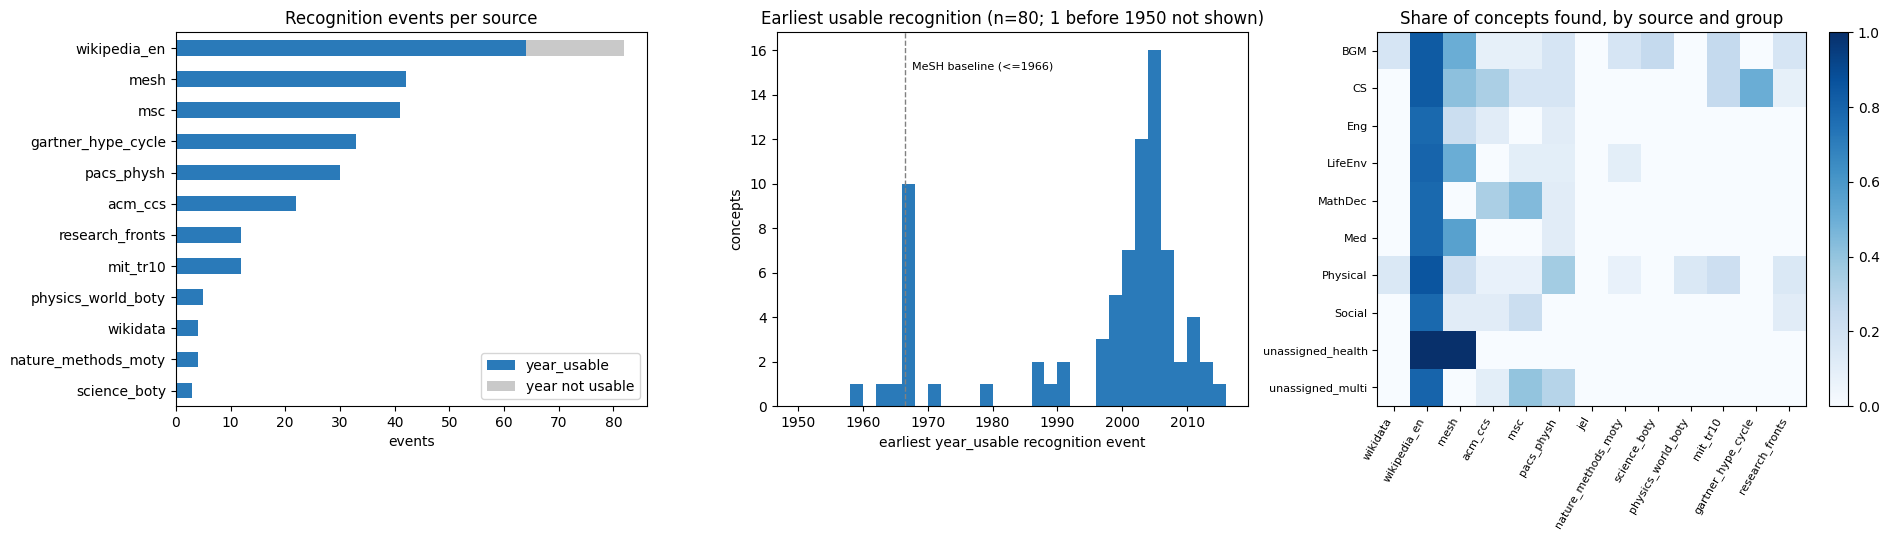

In [12]:
recs = []
for x in data["datasets"][0]["examples"][:N_EXAMPLES]:
    inp, out = json.loads(x["input"]), json.loads(x["output"])
    recs.append({"id": x["metadata_openalex_id"], "label": inp["label"], "level": x["metadata_level"],
                 "group": x["metadata_group"], "fold": x["metadata_fold"], "events": out["events"],
                 "sources_checked": out["sources_checked"], "present_day": out["present_day"]})

# 1) known-answer concepts: earliest usable year per source
KNOWN = ["Optogenetics", "Induced pluripotent stem cell", "CRISPR", "Super-resolution microscopy",
         "Genome editing", "Deep learning", "Graphene", "Blockchain", "Robotics"]
tab = []
for r in recs:
    if r["label"] in KNOWN:
        first = {}
        for e in r["events"]:
            if e["year_usable"] and e["year"] is not None:
                first[e["source"]] = min(first.get(e["source"], 9999), e["year"])
        tab.append({"concept": r["label"], "group": r["group"], "n_events": len(r["events"]), **first})
known_df = pd.DataFrame(tab).set_index("concept")
known_df = known_df[["group", "n_events"] + sorted(c for c in known_df.columns if c not in ("group", "n_events"))]
with pd.option_context("display.width", 250, "display.max_columns", 30):
    print("Earliest year_usable event per source (known-answer concepts)")
    print(known_df.map(lambda v: "" if pd.isna(v) else (int(v) if isinstance(v, float) else v)).to_string())

# 2) events per source; 3) earliest usable year per concept
ev = pd.DataFrame([{"source": e["source"], "year_usable": e["year_usable"], "relation": e["relation"],
                    "match_method": e["match_method"], "year": e["year"], "id": r["id"]}
                   for r in recs for e in r["events"]])
print(f"\n{len(recs)} concepts, {len(ev)} events, {ev['id'].nunique()} concepts with >=1 event")
print("\nEvents by match_method:\n", ev["match_method"].value_counts().to_string())
print("\nEvents by relation (from the external entry's side):\n", ev["relation"].value_counts().to_string())
first_year = ev[ev.year_usable & ev.year.notna()].groupby("id")["year"].min()

# 4) coverage: share of concepts with 'found*' per source and group
cov = pd.DataFrame([{"group": r["group"], **{s: str(v).startswith("found") for s, v in r["sources_checked"].items()}}
                    for r in recs]).groupby("group").mean()

fig, ax = plt.subplots(1, 3, figsize=(19, 5.5))
by_src = ev.groupby(["source", "year_usable"]).size().unstack(fill_value=0).reindex(columns=[True, False], fill_value=0)
by_src = by_src.loc[by_src.sum(axis=1).sort_values().index]
by_src.plot.barh(stacked=True, ax=ax[0], color=["#2a7ab9", "#c9c9c9"])
ax[0].legend(["year_usable", "year not usable"], loc="lower right"); ax[0].set_xlabel("events"); ax[0].set_ylabel("")
ax[0].set_title("Recognition events per source")
fy = first_year[first_year >= 1950]  # a few Wikidata inception dates reach back centuries; shown from 1950 on
ax[1].hist(fy.values, bins=range(1950, int(fy.max()) + 3, 2), color="#2a7ab9")
ax[1].axvline(1966.5, color="grey", ls="--", lw=1); ax[1].text(1967.5, ax[1].get_ylim()[1] * 0.9, "MeSH baseline (<=1966)", fontsize=8)
ax[1].set_xlabel("earliest year_usable recognition event"); ax[1].set_ylabel("concepts")
ax[1].set_title(f"Earliest usable recognition (n={len(first_year)}; {len(first_year) - len(fy)} before 1950 not shown)")
im = ax[2].imshow(cov.values, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax[2].set_xticks(range(cov.shape[1])); ax[2].set_xticklabels(cov.columns, rotation=60, ha="right", fontsize=8)
ax[2].set_yticks(range(cov.shape[0])); ax[2].set_yticklabels(cov.index, fontsize=8)
ax[2].set_title("Share of concepts found, by source and group")
fig.colorbar(im, ax=ax[2], fraction=0.04)
plt.tight_layout(); plt.show()